In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [18]:
df = pd.read_csv("../data/processed/latest.csv")
df.head()

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Title,Job_category,Level,Salary_Min,Salary_Max,Salary_Avg,Salary_Source
0,Sr Data Scientist,The Senior Data Scientist is responsible for d...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",sr data scientist,Data Scientist,Senior,137000,171000,154000.0,Glassdoor est.
1,Data Scientist,"Secure our Nation, Ignite your Future Join the...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),Unknown,data scientist,Data Scientist,Mid,137000,171000,154000.0,Glassdoor est.
2,Data Scientist,Analysis Group is one of the largest internati...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),Unknown,data scientist,Data Scientist,Mid,137000,171000,154000.0,Glassdoor est.
3,Data Scientist,Do you have a passion for Data and Machine Lea...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",data scientist,Data Scientist,Mid,137000,171000,154000.0,Glassdoor est.
4,Data Scientist,Data Scientist Affinity Solutions / Marketing ...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",data scientist,Data Scientist,Mid,137000,171000,154000.0,Glassdoor est.


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          551 non-null    object 
 1   Job Description    551 non-null    object 
 2   Rating             551 non-null    float64
 3   Company Name       551 non-null    object 
 4   Location           551 non-null    object 
 5   Headquarters       551 non-null    object 
 6   Size               551 non-null    object 
 7   Founded            551 non-null    int64  
 8   Type of ownership  551 non-null    object 
 9   Industry           551 non-null    object 
 10  Sector             551 non-null    object 
 11  Revenue            551 non-null    object 
 12  Competitors        551 non-null    object 
 13  Title              551 non-null    object 
 14  Job_category       551 non-null    object 
 15  Level              551 non-null    object 
 16  Salary_Min         551 non

How are salaries distributed in Data Science jobs?

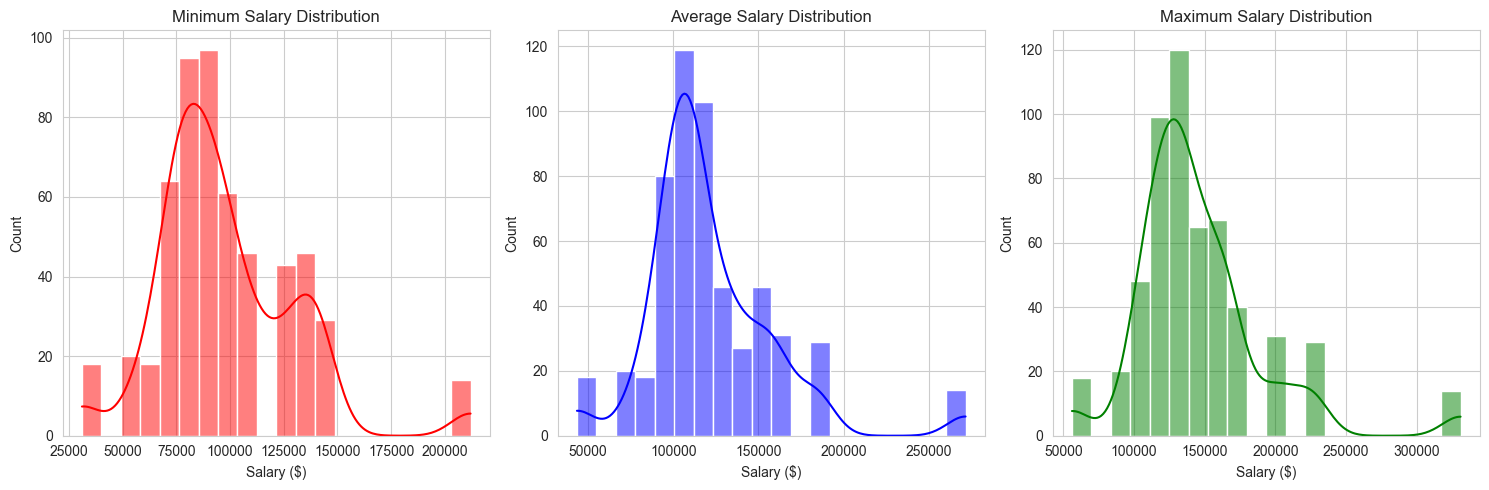

In [20]:
# Plot salary distribution
plt.figure(figsize=(15, 5))

# Minimum Salary
plt.subplot(1, 3, 1)
sns.histplot(df['Salary_Min'], bins=20, kde=True, color='red')
plt.title('Minimum Salary Distribution')
plt.xlabel('Salary ($)')

# Average Salary
plt.subplot(1, 3, 2)
sns.histplot(df['Salary_Avg'], bins=20, kde=True, color='blue')
plt.title('Average Salary Distribution')
plt.xlabel('Salary ($)')

# Maximum Salary
plt.subplot(1, 3, 3)
sns.histplot(df['Salary_Max'], bins=20, kde=True, color='green')
plt.title('Maximum Salary Distribution')
plt.xlabel('Salary ($)')

plt.tight_layout()
plt.show()

Most positions cluster around an average salary between $100,000 and $120,000, with minimum salaries typically ranging from $70,000 to $100,000 and maximum salaries commonly between $120,000 and $150,000. The distribution also shows a long tail toward higher salaries, indicating a smaller number of positions offering compensation above $200,000. This suggests that while the majority of roles fall within a relatively consistent salary band.

What are the most common job categories?

In [21]:
df["Job_category"].value_counts()

Job_category
Data Scientist                329
Other                          54
Data Analyst                   53
Data Engineer                  45
Scientist (Other)              33
Machine Learning Engineer      20
Machine Learning Scientist     11
Research Scientist              3
Analytics Manager               3
Name: count, dtype: int64

C:\Users\charl\AppData\Local\Temp\ipykernel_5140\4115670473.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


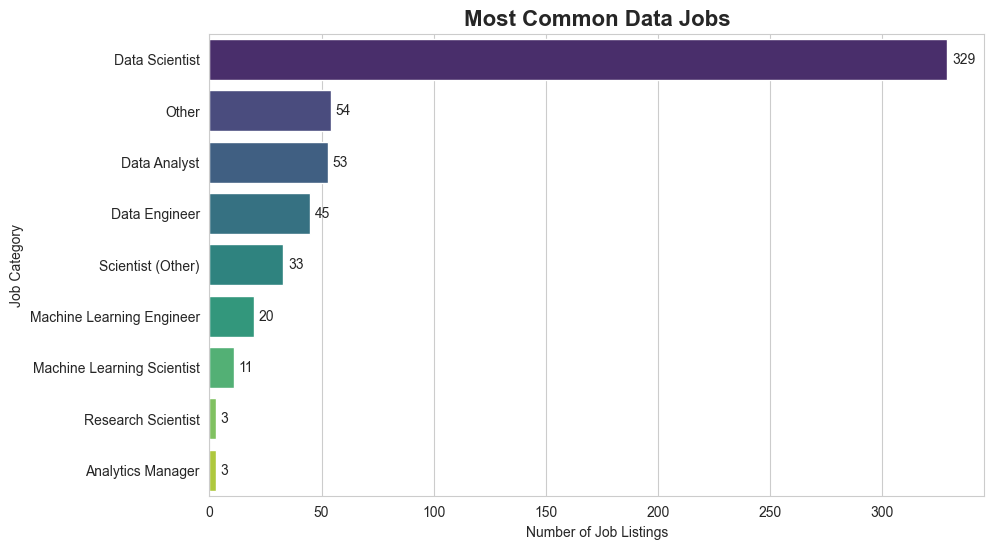

In [22]:
job_counts = df["Job_category"].value_counts()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=job_counts.values,
    y=job_counts.index,
    palette="viridis"
)

for i, v in enumerate(job_counts.values):
    ax.text(v + 2, i, str(v), va="center")

plt.title("Most Common Data Jobs", fontsize=16, weight="bold")
plt.xlabel("Number of Job Listings")
plt.ylabel("Job Category")

plt.show()

Data Scientist and Data Analyst roles dominate the dataset.

Which roles have the highest salaries?

In [23]:
salary_by_role = (
    df.groupby("Job_category")["Salary_Avg"]
    .mean()
    .sort_values(ascending=False)
)

salary_by_role

Job_category
Scientist (Other)             129590.909091
Other                         127666.666667
Data Scientist                122306.990881
Machine Learning Engineer     118075.000000
Data Analyst                  116575.471698
Data Engineer                 113366.666667
Machine Learning Scientist    109454.545455
Analytics Manager             102000.000000
Research Scientist             91000.000000
Name: Salary_Avg, dtype: float64

C:\Users\charl\AppData\Local\Temp\ipykernel_5140\1234343180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


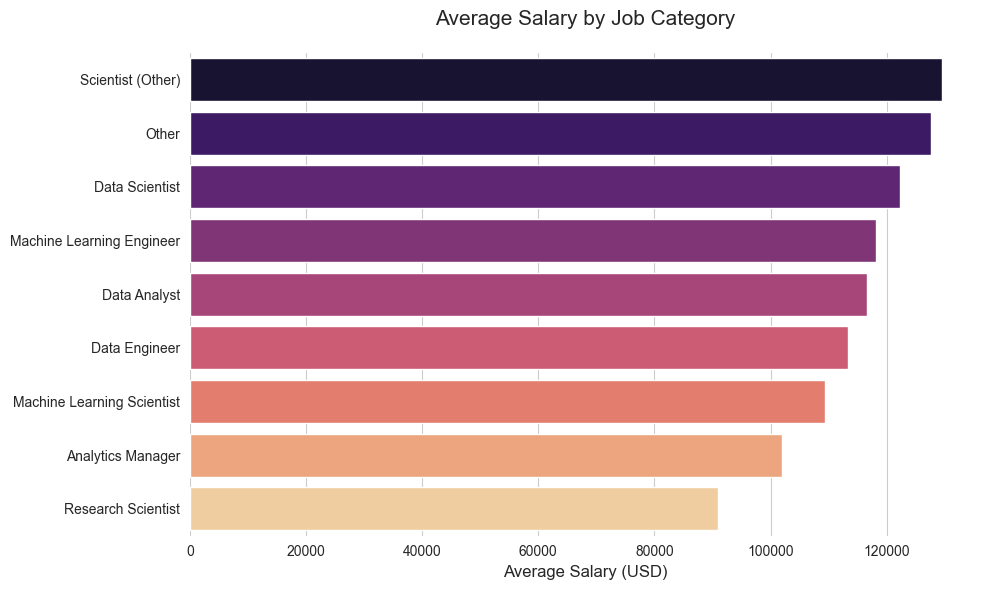

In [33]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=salary_by_role.values, 
    y=salary_by_role.index, 
    palette="magma" 
)

plt.title("Average Salary by Job Category", fontsize=15, pad=20)
plt.xlabel("Average Salary (USD)", fontsize=12)
plt.ylabel("") 

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Scientist roles tend to have higher salaries. It is notable that Machine Learning Scientist and Machine Learning Engineer have virtually identical salaries (around $109,000). This indicates that, for this data set, the market values ​​the research profile and the technical implementation profile in ML equally.

What is the distribution of seniority levels?

In [25]:
df["Level"].value_counts()

Level
Mid       454
Senior     91
Junior      6
Name: count, dtype: int64

C:\Users\charl\AppData\Local\Temp\ipykernel_5140\1935862663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


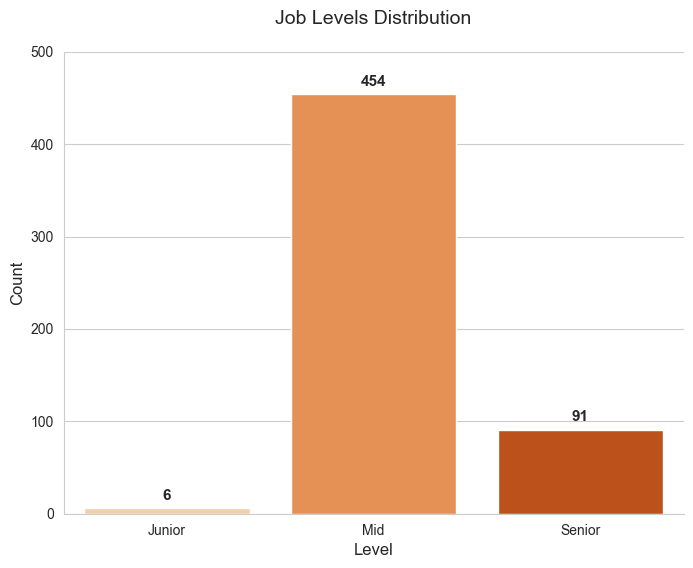

In [ ]:
plt.figure(figsize=(8, 6))

colors = ["#ffcc00", "#ff9900", "#ff6600"] 

ax = sns.countplot(
    x='Level', 
    data=df, 
    order=['Junior', 'Mid', 'Senior'],
    palette="Oranges"
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title("Job Levels Distribution", fontsize=14, pad=20)
plt.xlabel("Level", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.ylim(0, 500)
sns.despine()

plt.show()

Mid-level roles represent the majority of job postings. The market analyzed is not hiring new talent or has a very high barrier to entry that requires previous experience.

Which industries hire the most data professionals?

In [27]:
top_industries = df["Industry"].value_counts().head(10)

top_industries

Industry
Biotech & Pharmaceuticals                  63
Computer Hardware & Software               55
IT Services                                51
Enterprise Software & Network Solutions    42
Staffing & Outsourcing                     34
Aerospace & Defense                        34
Consulting                                 30
Insurance Carriers                         28
Internet                                   27
Advertising & Marketing                    21
Name: count, dtype: int64

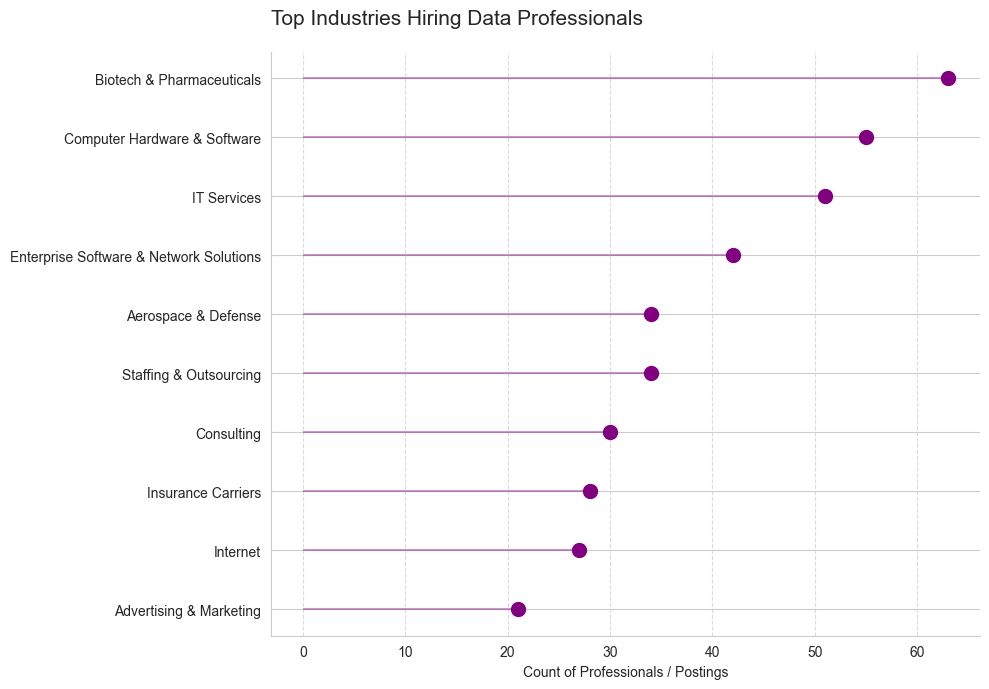

In [ ]:
df_sorted = top_industries.sort_values()

plt.figure(figsize=(10, 7))
plt.hlines(y=df_sorted.index, xmin=0, xmax=df_sorted.values, color='purple', alpha=0.4)
plt.plot(df_sorted.values, df_sorted.index, "o", markersize=10, color='purple')

plt.title("Top Industries Hiring Data Professionals", fontsize=15, loc='left', pad=20)
plt.xlabel("Count of Professionals / Postings")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Contrary to what many believe, the Biotech & Pharmaceuticals sector leads hiring. This explains why in the salary graph "Scientist (Other)" was the highest value. There is massive demand for data for genomics, precision medicine and clinical trials.

Which sectors hire the most data professionals?

In [29]:
top_sector = df["Sector"].value_counts().head(10)

top_sector

Sector
Information Technology          175
Business Services               108
Biotech & Pharmaceuticals        63
Aerospace & Defense              34
Finance                          32
Insurance                        32
Manufacturing                    23
Health Care                      18
Government                       17
Oil, Gas, Energy & Utilities     10
Name: count, dtype: int64

C:\Users\charl\AppData\Local\Temp\ipykernel_5140\2755946156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


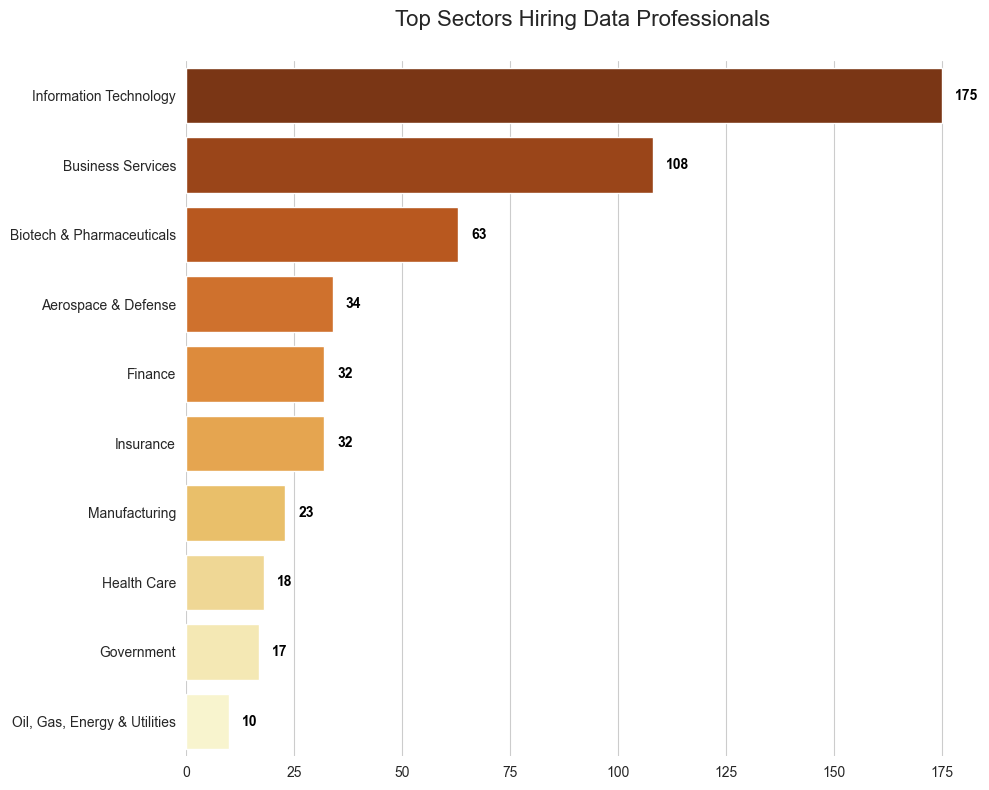

In [30]:
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=top_sector.values, 
    y=top_sector.index, 
    palette="YlOrBr_r"
)

for i, v in enumerate(top_sector.values):
    ax.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.title("Top Sectors Hiring Data Professionals", fontsize=16, pad=25)
plt.ylabel("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The Information Technology sector, not surprisingly, leads all other sectors, Business Services is in second place, this indicates that many companies that do not know how to manage data prefer to "rent" talent by hiring a consulting firm.


Do companies with higher ratings pay more?

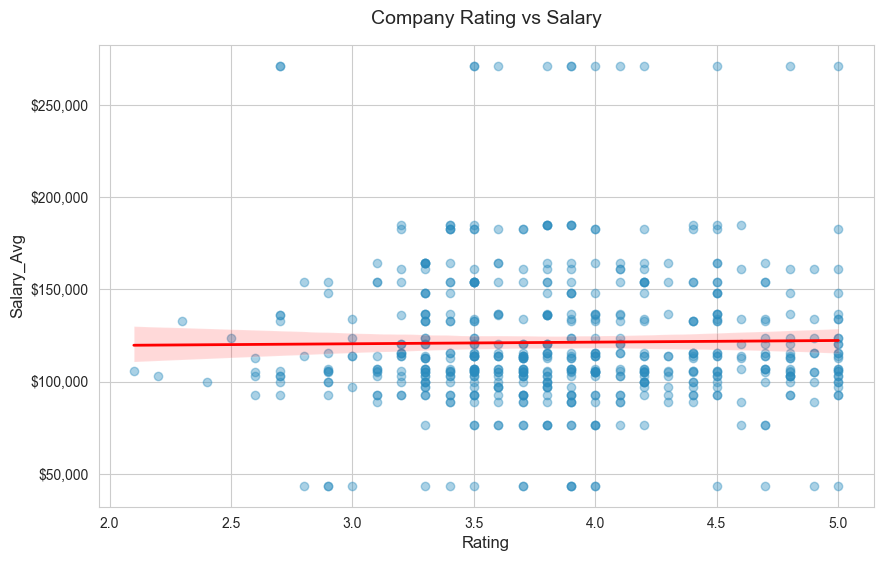

In [34]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='Rating', 
    y='Salary_Avg', 
    data=df, 
    scatter_kws={'alpha':0.4, 'color':'#2b8cbe'}, 
    line_kws={'color':'red', 'lw':2} 
)

plt.title("Company Rating vs Salary", fontsize=14, pad=15)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Salary_Avg", fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.show()

In [32]:
correlation = df[['Rating', 'Salary_Avg']].corr().iloc[0, 1]
print(f"Correlation between Rating and Average Salary: {correlation:.3f}")

Correlation between Rating and Average Salary: 0.014


No strong correlation between company rating and salary. This means that a better company rating does not guarantee a better salary.

Although the Technology and Health sector is the one that demands the most professionals and pays the best, the reputation of the company (Rating) is not a reliable indicator to predict salary. Salary is more tied to the specific role and sector than to how happy people are working there
